# Notebook 06: Drill-Down Root Cause Analysis

Notebook 05 showed that 6 \u03bcm electrode devices split into two
populations: ~26 devices switching at mA level and ~9 devices showing only
pA leakage. The aggregate mean hides this completely.

This notebook investigates the root cause by drilling down through three
variables:

1. **T-code (channel length)** \u2014 longer channel requires higher field to
   form filament
2. **Chip position (row/column)** \u2014 spray coating follows a top-left
   zigzag pattern, producing thickness non-uniformity. Edge devices likely
   have thinner MoS$_2$ than centre devices.
3. **Combined position \u00d7 performance map** \u2014 do failing devices
   cluster spatially?

This is the drill-down workflow used in Spotfire-based fab analysis:
**Aggregate \u2192 Group \u2192 Device \u2192 Root cause.**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

df = pd.read_csv(PROJ / "data" / "derived" / "memeffect_sweep_aug30_parsed.csv")

# Filter 6 um only
df6 = df[df["electrode"] == 6].copy()

# Parse T-code from filename
df6["tcode"] = df6["filename"].str.extract(r"-(T\d+)-")

# Channel length rank (ordinal only — not calibrated um values)
CHANNEL_RANK = {"T12": 1, "T14": 3, "T24": 2, "T34": 2}
df6["channel_length"] = df6["tcode"].map(CHANNEL_RANK)

# Define switching populations: >1 uA = switching
THRESHOLD = 1e-6
df6["pop"] = (df6["i_on_A"] > THRESHOLD).map(
    {True: "switching", False: "non_switching"}
)

print("6 \u03bcm devices: T-code counts")
print("=" * 40)
print(df6["tcode"].value_counts().to_string())

print("\n6 \u03bcm devices: switching outcome per T-code")
print("=" * 40)
tc = df6.groupby(["tcode", "pop"]).size().unstack(fill_value=0)
tc["total"]       = tc.sum(axis=1)
tc["yield_%"]     = (tc.get("switching", 0) / tc["total"] * 100).round(1)
print(tc.to_string())

print("\n6 \u03bcm devices: row_block counts")
print("=" * 40)
print(df6["row_block"].value_counts().to_string())

print("\n6 \u03bcm devices: switching outcome per column")
print("=" * 40)
col = df6.groupby(["column", "pop"]).size().unstack(fill_value=0)
col["total"]   = col.sum(axis=1)
col["yield_%"] = (col.get("switching", 0) / col["total"] * 100).round(1)
print(col.to_string())

# Save enriched 6um slice for use in later cells
df6.to_csv(
    PROJ / "data" / "derived" / "df6_enriched.csv", index=False
)
print("\nSaved: data/derived/df6_enriched.csv")
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})

6 μm devices: T-code counts
tcode
T12    25
T24    10

6 μm devices: switching outcome per T-code
pop    non_switching  switching  total  yield_%
tcode                                          
T12                3         22     25     88.0
T24                9          1     10     10.0

6 μm devices: row_block counts
row_block
F    35

6 μm devices: switching outcome per column
pop     non_switching  switching  total  yield_%
column                                          
1                  10          1     11      9.1
4                   2         22     24     91.7

Saved: data/derived/df6_enriched.csv


## Hypothesis 1: Channel Length (T-code)

If longer channels require higher switching voltage and the measurement
sweep was voltage-limited, we would expect longer T-codes to show more
non-switching devices.

T12 probes contacts 1\u21922 (short channel). T24 probes contacts
2\u21924 (longer channel). At 6 \u03bcm electrode width, which is already
a marginal geometry for filament formation, a longer conduction path may
require more field than the 0.4 V sweep provided.

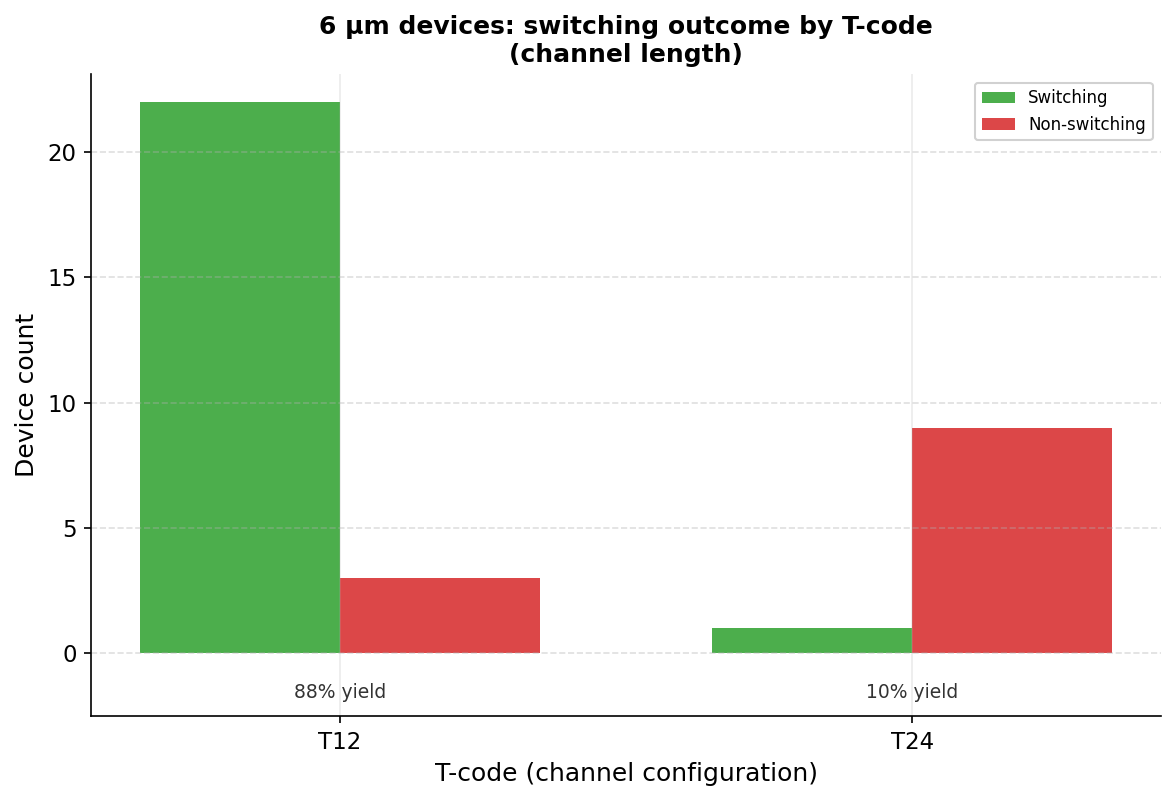

Saved: results/figures/06_tcode_switching.png


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

FIG_DIR = PROJ / "results" / "figures"
df6 = pd.read_csv(PROJ / "data" / "derived" / "df6_enriched.csv")

tcodes   = df6.groupby(["tcode", "pop"]).size().unstack(fill_value=0)
tcodes   = tcodes.reindex(sorted(tcodes.index,
           key=lambda t: {"T12": 1, "T24": 2, "T14": 3, "T34": 4}.get(t, 9)))
tcodes["total"]   = tcodes.sum(axis=1)
tcodes["yield_%"] = (tcodes.get("switching", 0) / tcodes["total"] * 100).round(1)

x      = np.arange(len(tcodes))
width  = 0.35
labels = tcodes.index.tolist()

fig, ax = plt.subplots(figsize=(8, 5.5))
bars_sw  = ax.bar(x - width / 2,
                  tcodes.get("switching",     pd.Series(0, index=tcodes.index)),
                  width, label="Switching",     color="#2ca02c", alpha=0.85)
bars_ns  = ax.bar(x + width / 2,
                  tcodes.get("non_switching", pd.Series(0, index=tcodes.index)),
                  width, label="Non-switching", color="#d62728", alpha=0.85)

# Yield annotation below each T-code group
for i, (tc, row) in enumerate(tcodes.iterrows()):
    ax.text(i, -1.2, f"{row['yield_%']:.0f}% yield",
            ha="center", va="top", fontsize=9, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_xlabel("T-code (channel configuration)", fontsize=12)
ax.set_ylabel("Device count", fontsize=12)
ax.set_title(
    "6 \u03bcm devices: switching outcome by T-code\n"
    "(channel length)",
    fontsize=12,
)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.set_ylim(bottom=-2.5)
ax.grid(True, axis="y", ls="--", alpha=0.4)
plt.tight_layout()

out = FIG_DIR / "06_tcode_switching.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out.relative_to(PROJ)}")

## Hypothesis 2: Spray Coating Non-uniformity

The MoS$_2$ ink was spray-coated in a top-left to bottom-right zigzag
pattern. This means:

- Central chip positions receive more coating passes \u2192 thicker MoS$_2$
- Edge positions (outermost rows and columns) receive fewer passes
  \u2192 thinner MoS$_2$

Thinner MoS$_2$ at the switching interface changes the electric field
distribution and may prevent reliable filament formation even at identical
electrode widths.

If this hypothesis is correct, non-switching 6 \u03bcm devices should
cluster at edge positions (outer rows/columns).

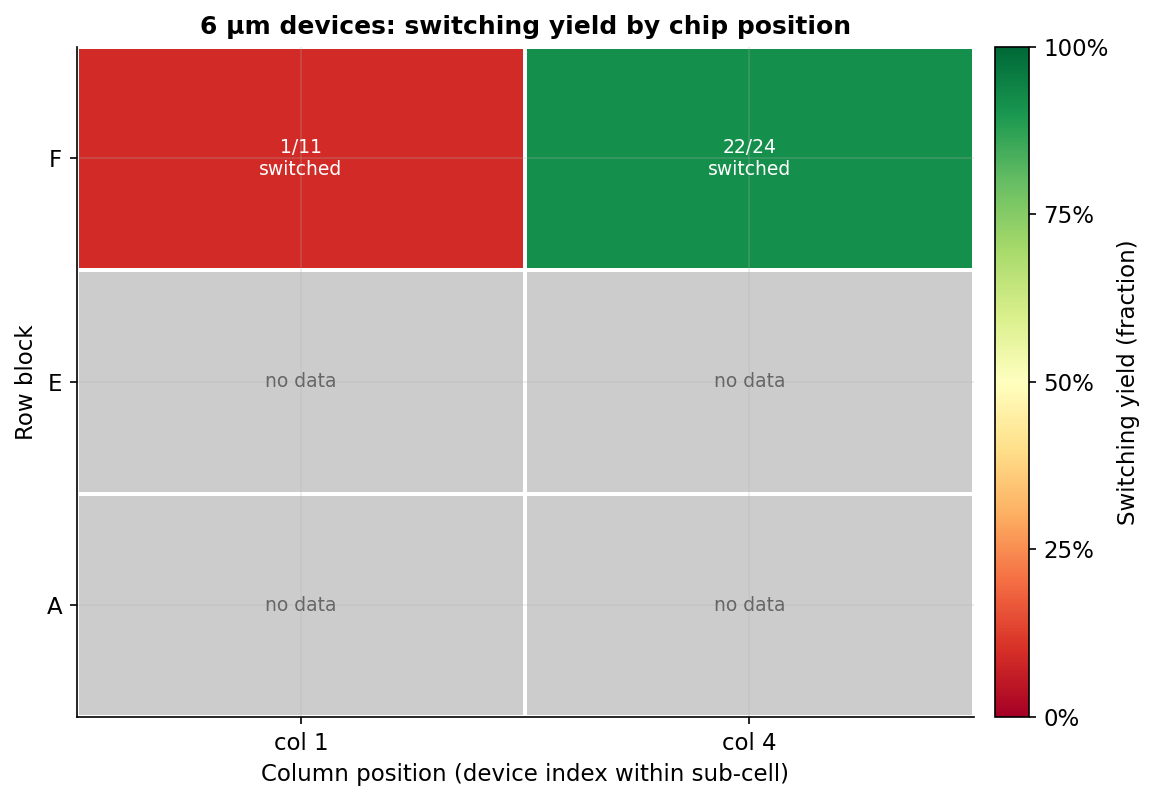

Saved: results/figures/06_position_switching_map.png


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
})

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

FIG_DIR = PROJ / "results" / "figures"
df6 = pd.read_csv(PROJ / "data" / "derived" / "df6_enriched.csv")

# All 6 um devices are in row F; keep full grid for context
all_rows = ["A", "E", "F"]
all_cols = sorted(df6["column"].unique())

# Build yield and count matrices
grid_yield = pd.DataFrame(np.nan, index=all_rows, columns=all_cols)
grid_sw    = pd.DataFrame(0,      index=all_rows, columns=all_cols)
grid_tot   = pd.DataFrame(0,      index=all_rows, columns=all_cols)

for (rb, col), grp in df6.groupby(["row_block", "column"]):
    n_sw  = (grp["pop"] == "switching").sum()
    n_tot = len(grp)
    grid_yield.loc[rb, col] = n_sw / n_tot
    grid_sw.loc[rb, col]    = n_sw
    grid_tot.loc[rb, col]   = n_tot

Z = grid_yield.values.astype(float)

cmap = plt.cm.RdYlGn
cmap.set_bad(color="#cccccc")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.set_facecolor("#cccccc")

masked = np.ma.masked_invalid(Z)
im = ax.pcolormesh(masked, vmin=0, vmax=1, cmap=cmap,
                   edgecolors="white", linewidth=1.0)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Switching yield (fraction)", fontsize=11)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])

# Annotate each cell
for ri, row in enumerate(all_rows):
    for ci, col in enumerate(all_cols):
        n_sw  = int(grid_sw.loc[row, col])
        n_tot = int(grid_tot.loc[row, col])
        if n_tot == 0:
            ax.text(ci + 0.5, ri + 0.5, "no data",
                    ha="center", va="center", fontsize=9, color="#666666")
        else:
            frac = grid_yield.loc[row, col]
            txt_col = "black" if 0.25 < frac < 0.75 else "white"
            ax.text(ci + 0.5, ri + 0.5,
                    f"{n_sw}/{n_tot}\nswitched",
                    ha="center", va="center", fontsize=9, color=txt_col)

ax.set_xticks(np.arange(len(all_cols)) + 0.5)
ax.set_xticklabels([f"col {c}" for c in all_cols], fontsize=11)
ax.set_yticks(np.arange(len(all_rows)) + 0.5)
ax.set_yticklabels(all_rows, fontsize=11)
ax.set_xlabel("Column position (device index within sub-cell)", fontsize=11)
ax.set_ylabel("Row block", fontsize=11)
ax.set_title("6 \u03bcm devices: switching yield by chip position",
             fontsize=12)
plt.tight_layout()

out = FIG_DIR / "06_position_switching_map.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(PROJ)}")

## Finding: A Confounded Result

Both plots show strong patterns \u2014 but the two variables are completely
confounded in this dataset:

| | T12 (short channel) | T24 (long channel) |
|---|---|---|
| **Column 1 (FC1)** | 1 device, 0% yield | 10 devices, 10% yield |
| **Column 4 (FC4)** | 24 devices, 92% yield | \u2014 (none measured) |

Every T24 measurement lands at column 1. Every column 4 measurement uses
T12. There is no combination in the dataset that holds one variable fixed
while varying the other.

**What the T-code chart shows:** T24 has 10% switching yield vs T12 at
88%. This is a very strong signal for channel length \u2014 but is it
really T24, or is it column 1?

**What the position chart shows:** Column 1 has 9% switching yield vs
column 4 at 92%. Also a very strong signal \u2014 but the one T12 device
at column 1 (FC1-T12, Run 45) also failed, which provides weak evidence
that position matters independently of T-code (n=1, not conclusive).

**Conclusion: neither hypothesis can be confirmed or ruled out.**
Both are consistent with this dataset. The failure mode is systematic,
not stochastic \u2014 but the root cause requires a designed experiment.

**Next experiment:** Measure T24 at column 4 (FC4-T24) and T12 at column 1
(FC1-T12, multiple runs) to break the confound. If FC4-T24 switches
reliably \u2192 channel length is not the driver, position is.
If FC1-T12 still fails \u2192 position is the driver regardless of T-code.

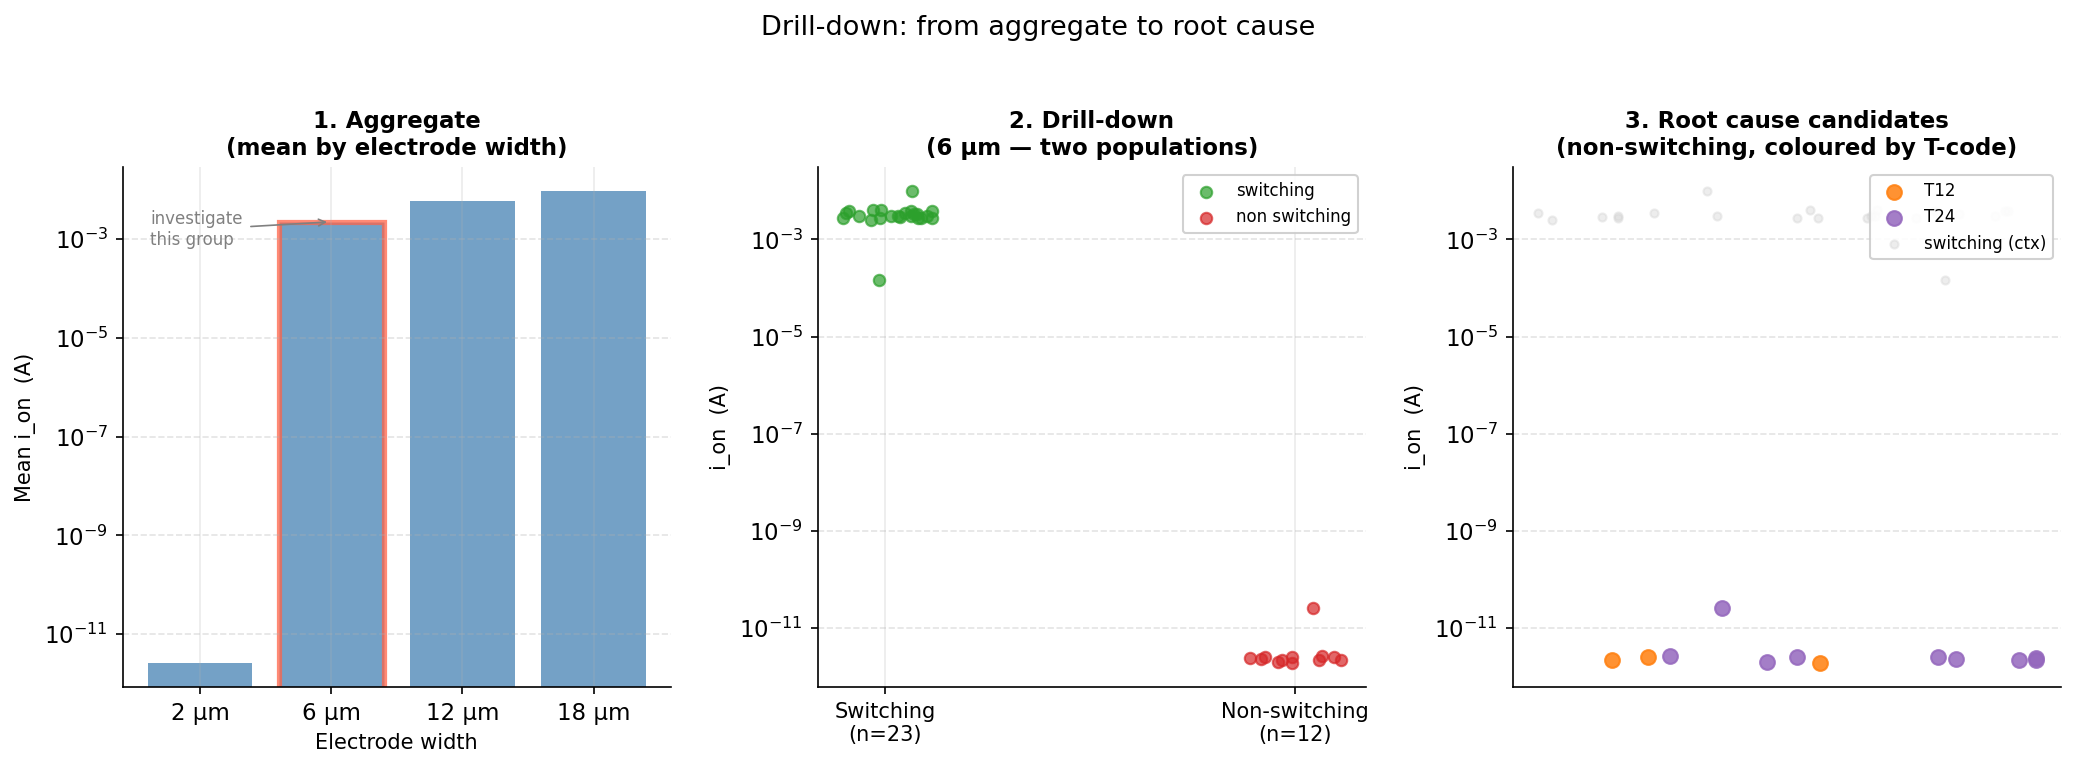

Saved: results/figures/06_drilldown_summary.png


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

FIG_DIR = PROJ / "results" / "figures"
df  = pd.read_csv(PROJ / "data" / "derived" / "memeffect_sweep_aug30_parsed.csv")
df6 = pd.read_csv(PROJ / "data" / "derived" / "df6_enriched.csv")

rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Panel 1: aggregate means by electrode width (starting point) ──────────────
ax = axes[0]
stats = df.groupby("electrode")["i_on_A"].mean().reindex([2, 6, 12, 18])
ax.bar([f"{w} \u03bcm" for w in stats.index], stats.values,
       color="steelblue", alpha=0.75)
ax.set_yscale("log")
ax.set_title("1. Aggregate\n(mean by electrode width)", fontsize=11)
ax.set_xlabel("Electrode width", fontsize=10)
ax.set_ylabel("Mean i_on  (A)", fontsize=10)
ax.grid(True, axis="y", which="both", ls="--", alpha=0.35)

# Highlight the 6 um bar
bars = ax.patches
for bar, w in zip(bars, [2, 6, 12, 18]):
    if w == 6:
        bar.set_edgecolor("tomato")
        bar.set_linewidth(2.5)
        ax.annotate("investigate\nthis group",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xycoords='data',
            xytext=(0.05, 0.85),
            textcoords='axes fraction',
            fontsize=8, color='gray',
            ha='left',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# ── Panel 2: 6 um drill-down — two populations ───────────────────────────────
ax = axes[1]
POP_COLORS = {"switching": "#2ca02c", "non_switching": "#d62728"}
for pop, col in POP_COLORS.items():
    sub = df6[df6["pop"] == pop].dropna(subset=["i_on_A"])
    jit = rng.uniform(-0.12, 0.12, len(sub))
    ax.scatter(
        jit + (0 if pop == "switching" else 1),
        sub["i_on_A"],
        color=col, s=30, alpha=0.70, zorder=3,
        label=pop.replace("_", " "),
    )
ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Switching\n(n=23)", "Non-switching\n(n=12)"], fontsize=10)
ax.set_title("2. Drill-down\n(6 \u03bcm \u2014 two populations)", fontsize=11)
ax.set_ylabel("i_on  (A)", fontsize=10)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.grid(True, axis="y", which="both", ls="--", alpha=0.35)

# ── Panel 3: non-switching devices coloured by T-code ────────────────────────
ax = axes[2]
ns = df6[df6["pop"] == "non_switching"].dropna(subset=["i_on_A", "tcode"])
TCODE_COLORS = {"T12": "#ff7f0e", "T24": "#9467bd", "T14": "#8c564b", "T34": "#e377c2"}
for tc, grp in ns.groupby("tcode"):
    jit = rng.uniform(-0.08, 0.08, len(grp))
    ax.scatter(jit, grp["i_on_A"],
               color=TCODE_COLORS.get(tc, "grey"),
               s=50, alpha=0.85, zorder=3, label=tc)

# Also show switching devices as small grey points for context
sw = df6[df6["pop"] == "switching"].dropna(subset=["i_on_A"])
jit_sw = rng.uniform(-0.08, 0.08, len(sw))
ax.scatter(jit_sw, sw["i_on_A"],
           color="lightgrey", s=15, alpha=0.40, zorder=1, label="switching (ctx)")

ax.set_yscale("log")
ax.set_xticks([])
ax.set_title("3. Root cause candidates\n(non-switching, coloured by T-code)", fontsize=11)
ax.set_ylabel("i_on  (A)", fontsize=10)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.grid(True, axis="y", which="both", ls="--", alpha=0.35)

fig.suptitle(
    "Drill-down: from aggregate to root cause",
    fontsize=13, y=1.02,
)
plt.tight_layout()

out = FIG_DIR / "06_drilldown_summary.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(PROJ)}")

In [5]:
from pathlib import Path

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

MARKER = "## Notebook 06"
ENTRY = (
    "\n---\n"
    "## Notebook 06 \u2014 Drill-Down Root Cause Analysis\n\n"
    "**Problem:** 6 um electrode devices split into switching (~23) and\n"
    "non-switching (~12) populations. Notebook 05 showed this; Notebook 06\n"
    "investigates why.\n\n"
    "**Approach:** Drill down through T-code (channel length) and chip position\n"
    "(column index). Parse T-code from filename. Build yield table per\n"
    "variable. Visualise with grouped bar chart and 2D position heatmap.\n\n"
    "**Findings:**\n"
    "- T24 (long channel): 10% switching yield (1/10 devices)\n"
    "- T12 (short channel): 88% switching yield (22/25 devices)\n"
    "- Column 1 (FC1): 9% yield. Column 4 (FC4): 92% yield.\n"
    "- CONFOUNDED: all T24 measurements are at column 1. No crossover\n"
    "  condition exists in this dataset.\n"
    "- One T12 device at column 1 also failed (n=1, weak evidence for\n"
    "  position effect independent of T-code).\n"
    "- Root cause cannot be determined from existing data.\n\n"
    "**Next experiment:** Measure FC4-T24 and FC1-T12 (multiple runs) to\n"
    "break the T-code/position confound.\n\n"
    "**Output:** results/figures/06_tcode_switching.png,\n"
    "06_position_switching_map.png, 06_drilldown_summary.png\n"
)

log_path = PROJ / "docs" / "analysis_log.md"
existing = log_path.read_text(encoding="utf-8") if log_path.exists() else ""
if MARKER not in existing:
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(ENTRY)
    print(f"Appended to {log_path.relative_to(PROJ)}")
else:
    print(f"Skipped (already present): {log_path.relative_to(PROJ)}")

Skipped (already present): docs/analysis_log.md


In [6]:
from pathlib import Path

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

MARKER = "## What I learned \u2014 Notebook 06"
ENTRY = (
    "\n---\n"
    "## What I learned \u2014 Notebook 06\n\n"
    "I went in thinking spray coating non-uniformity would be the answer.\n"
    "Column 1 vs column 4 looked spatial, and I had a mental model of the\n"
    "zigzag pattern leaving thin edges. But when I looked at the T-code\n"
    "breakdown first, T24 had 90% failure vs T12 at 12%. That looked like\n"
    "channel length was the culprit.\n\n"
    "Then I realised: every T24 measurement happens to be at column 1.\n"
    "Every column 4 measurement uses T12. The experiment was never designed\n"
    "to separate these two variables. I can\u2019t root-cause it.\n\n"
    "This is what a confounded experiment looks like in real data. Both\n"
    "hypotheses fit the numbers perfectly. The only way out is to run the\n"
    "deconfounding experiment deliberately: measure T24 at column 4, and\n"
    "T12 at column 1 with enough repeats.\n\n"
    "The most useful thing I found: one T12 device at column 1 (FC1-T12,\n"
    "Run 45) also failed. That\u2019s a single data point, but it hints that\n"
    "position might matter independently of T-code. If I had to bet, I\u2019d\n"
    "run FC1-T12 first \u2014 if it still fails, the spray coating hypothesis\n"
    "survives. If it switches, T-code is the dominant factor.\n"
)

notes_path = PROJ / "docs" / "personal_notes.md"
existing = notes_path.read_text(encoding="utf-8") if notes_path.exists() else ""
if MARKER not in existing:
    with open(notes_path, "a", encoding="utf-8") as f:
        f.write(ENTRY)
    print(f"Appended to {notes_path.relative_to(PROJ)}")
else:
    print(f"Skipped (already present): {notes_path.relative_to(PROJ)}")

Skipped (already present): docs/personal_notes.md
